# Assignment 1: Vertebral Column Data Set

Name: **Pratham Aggarwal** | GitHub: **prathamaeron** | USC ID: **1537722913**

## Importing the Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

## Reading the Data

In [32]:
column_2C = pd.read_csv(
    '../data/column_2C.dat',
    sep=r'\s+',
    header=None,
)

features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis',
]

column_2C.columns = features + ['class']

column_2C['class'] = column_2C['class'].map({
    'NO': 0,
    'AB': 1,
})

## Pre-Processing and Exploratory Data Analysis

(i) Make scatterplots of the independent variables in the dataset. Use color to show Classes 0 and 1.

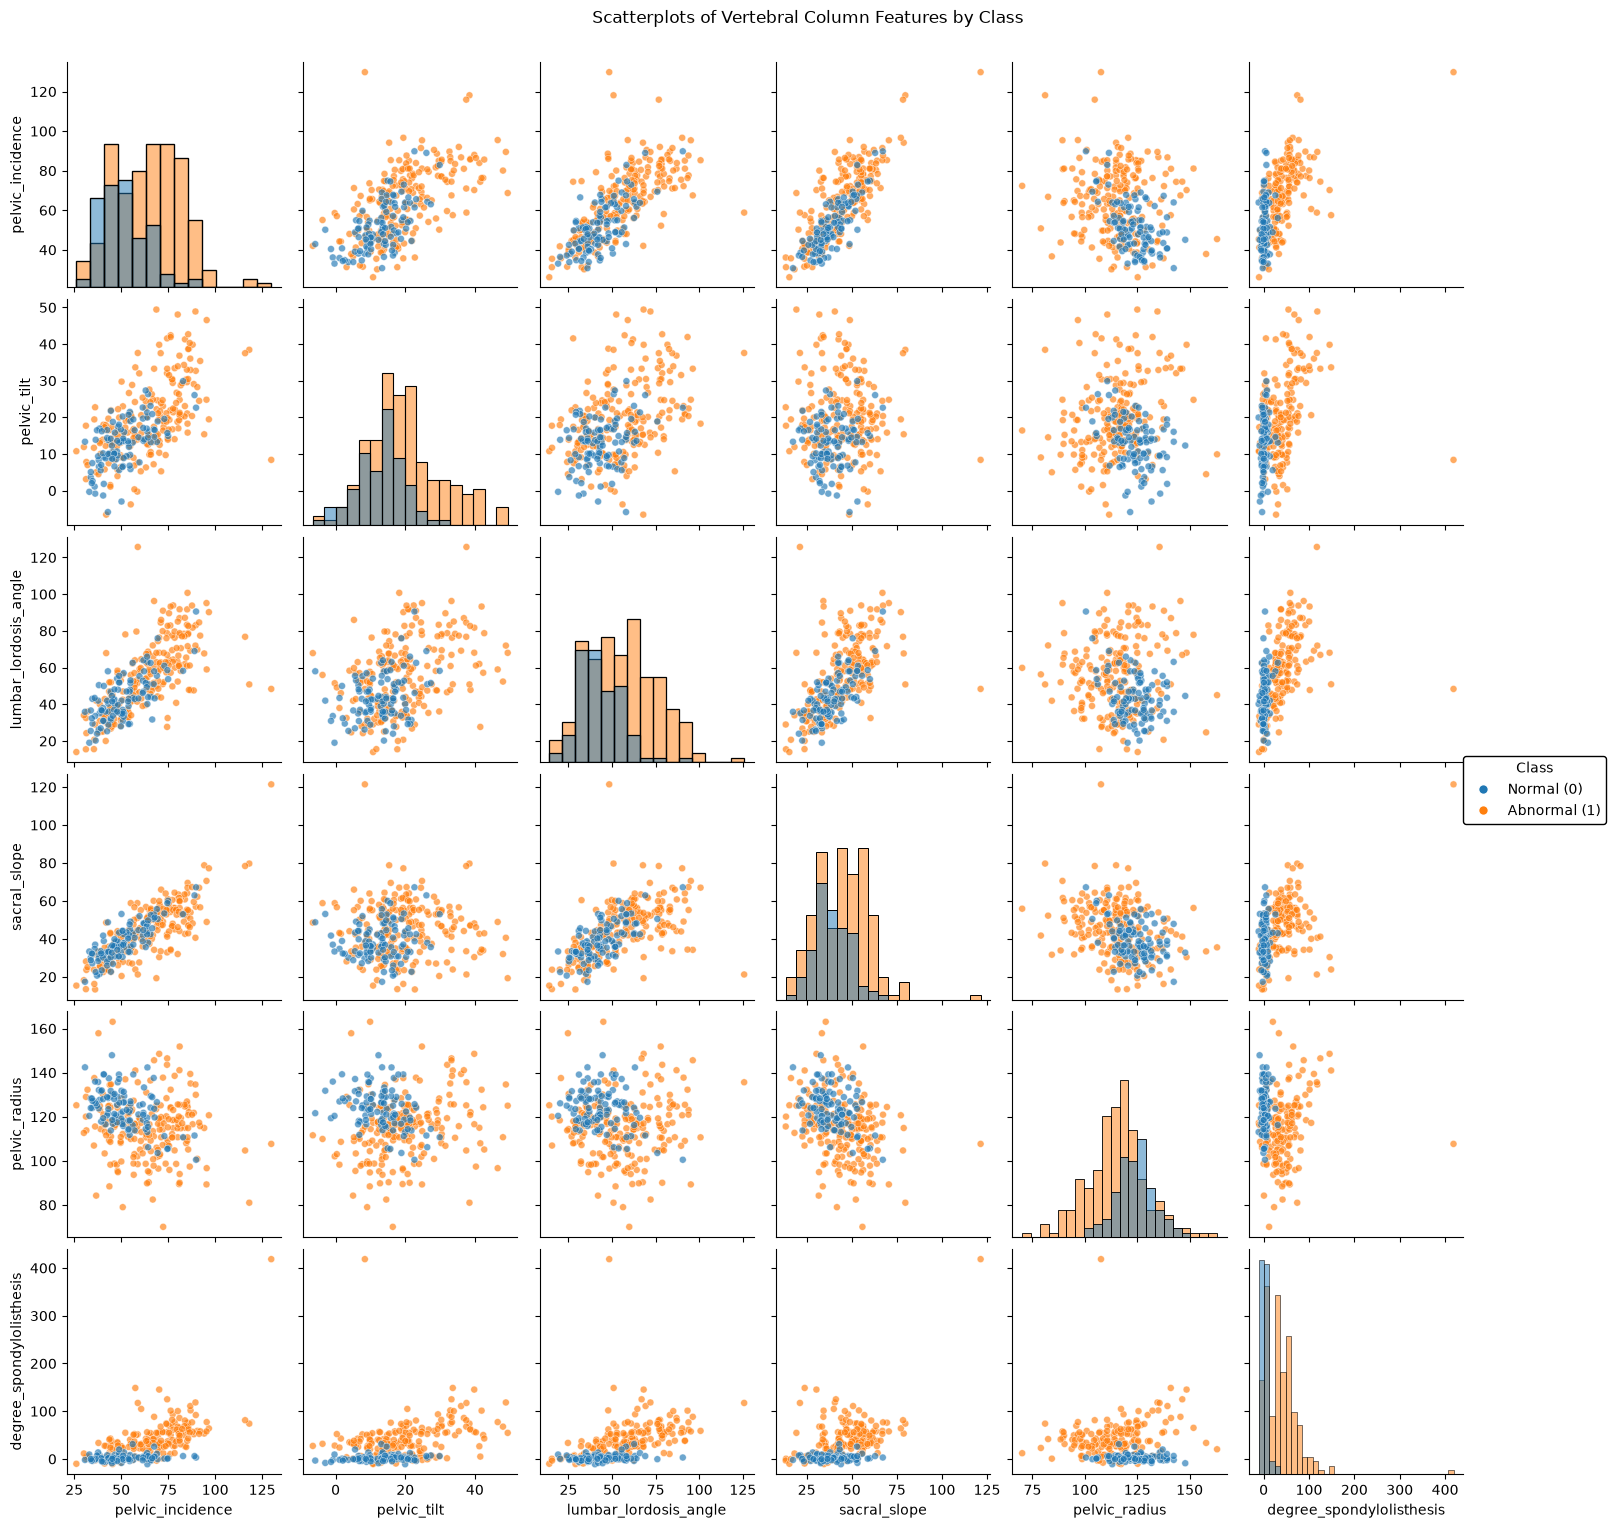

In [33]:
normal = column_2C[column_2C['class'] == 0]
abnormal = column_2C[column_2C['class'] == 1]

plot_data = column_2C[features + ['class']].copy()
plot_data['class'] = plot_data['class'].map({
    0: 'Normal (0)',
    1: 'Abnormal (1)',
})

pair_plot = sns.pairplot(
    plot_data,
    vars=features,
    hue='class',
    hue_order=['Normal (0)', 'Abnormal (1)'],
    palette={'Normal (0)': 'tab:blue', 'Abnormal (1)': 'tab:orange'},
    diag_kind='hist',
    plot_kws={'alpha': 0.65, 's': 25},
)

pair_plot.figure.suptitle(
    'Scatterplots of Vertebral Column Features by Class',
    y=1.02,
)

pair_plot._legend.remove()
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Normal (0)',
        markerfacecolor='tab:blue',
        markersize=7,
    ),
    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Abnormal (1)',
        markerfacecolor='tab:orange',
        markersize=7,
    ),
]

pair_plot.figure.legend(
    handles=legend_handles,
    title='Class',
    loc='center right',
    bbox_to_anchor=(0.99, 0.5),
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=1.0,
)

plt.show()

(ii) Make boxplots for each of the independent variables. Use color to show Classes 0 and 1

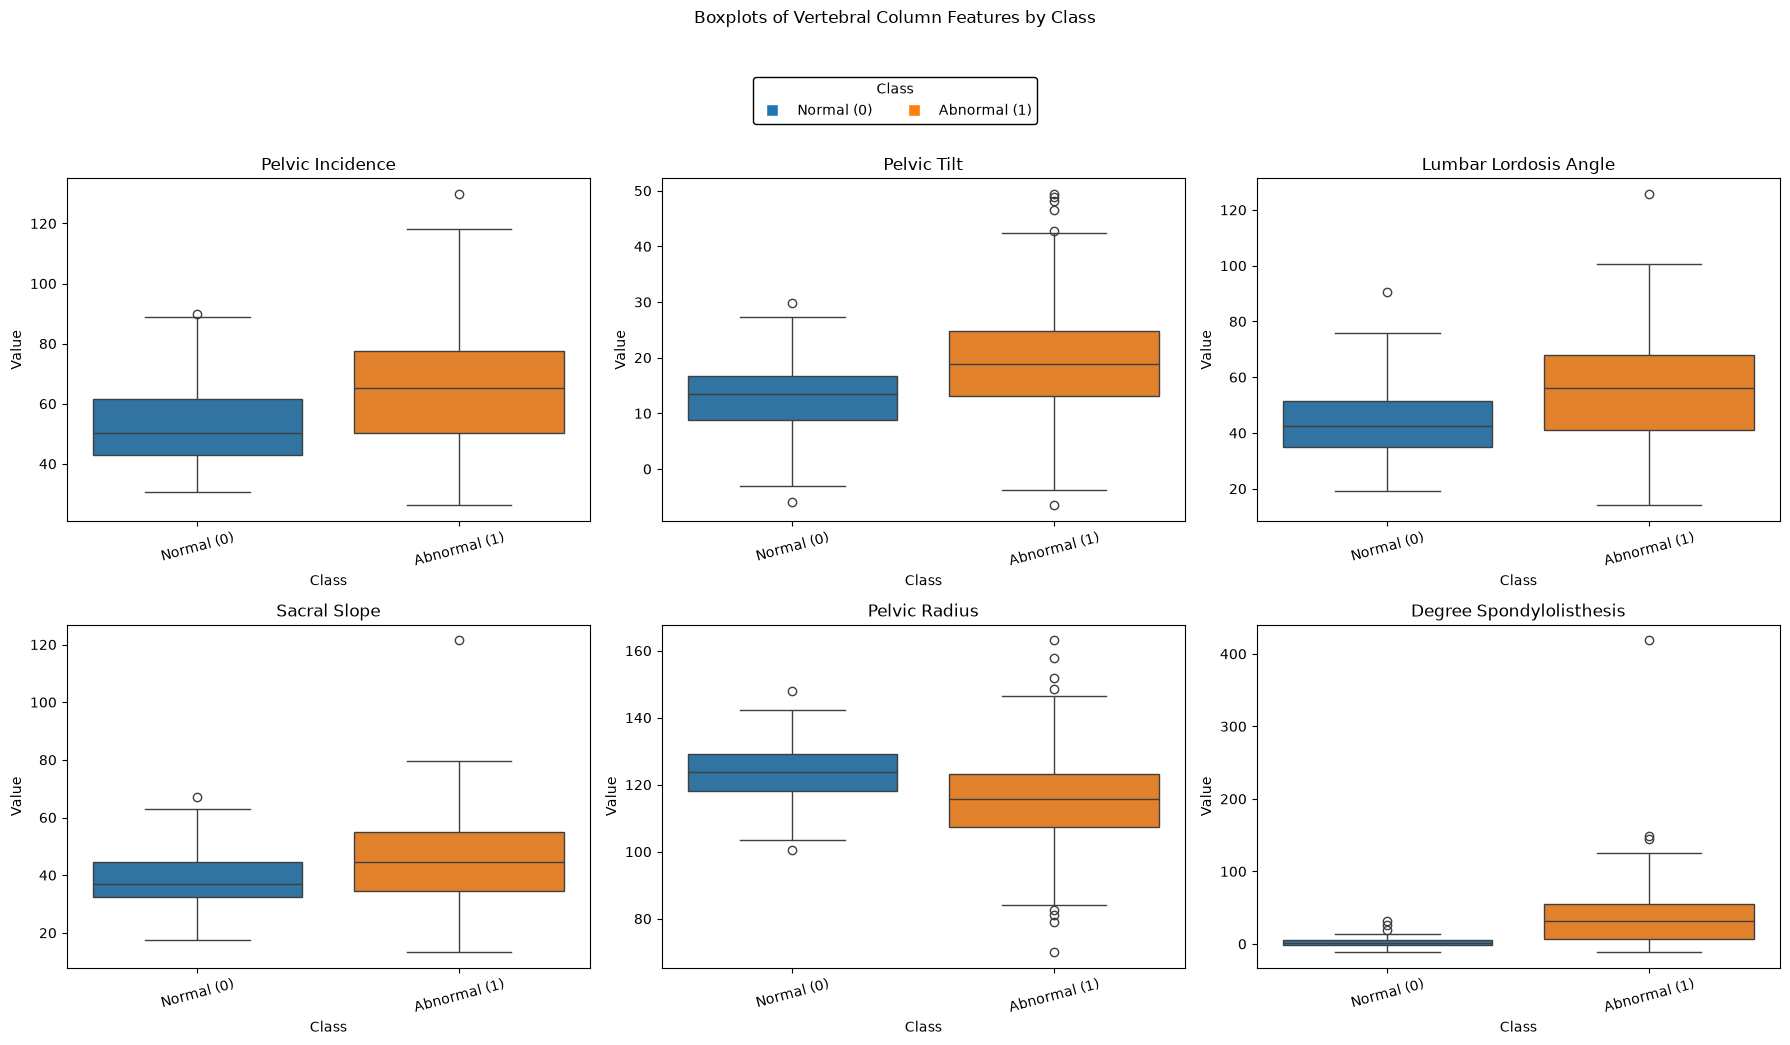

In [34]:
boxplot_data = column_2C.copy()
boxplot_data['class_label'] = boxplot_data['class'].map({
    0: 'Normal (0)',
    1: 'Abnormal (1)',
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

boxplot_palette = {
    'Normal (0)': 'tab:blue',
    'Abnormal (1)': 'tab:orange',
}

for axis, feature in zip(axes, features):
    sns.boxplot(
        data=boxplot_data,
        x='class_label',
        y=feature,
        hue='class_label',
        order=['Normal (0)', 'Abnormal (1)'],
        hue_order=['Normal (0)', 'Abnormal (1)'],
        palette=boxplot_palette,
        legend=False,
        ax=axis,
    )
    axis.set_title(feature.replace('_', ' ').title())
    axis.set_xlabel('Class')
    axis.set_ylabel('Value')
    axis.tick_params(axis='x', rotation=15)

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker='s',
        color='w',
        label='Normal (0)',
        markerfacecolor='tab:blue',
        markersize=9,
    ),
    plt.Line2D(
        [0],
        [0],
        marker='s',
        color='w',
        label='Abnormal (1)',
        markerfacecolor='tab:orange',
        markersize=9,
    ),
]

fig.legend(
    handles=legend_handles,
    title='Class',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=1.0,
)

fig.suptitle('Boxplots of Vertebral Column Features by Class', y=1.04)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

(iii) Select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the training set and the rest of the data as the test set.

In [35]:
train = pd.concat([
    normal.iloc[:70],
    abnormal.iloc[:140],
])

test = pd.concat([
    normal.iloc[70:],
    abnormal.iloc[140:],
])

## Classification using KNN on Vertebral Column Data Set

(i) Write code for k-nearest neighbors with Euclidean metric (or use a software package)

In [36]:
X_train = train[features]
y_train = train['class']

knn_euclidean = KNeighborsClassifier(
    n_neighbors=1,
    metric='euclidean',
)
knn_euclidean.fit(X_train, y_train)

train_predictions = knn_euclidean.predict(X_train)

print(f'Training observations: {len(X_train)}')
print(f'Training accuracy: {knn_euclidean.score(X_train, y_train):.3f}')

Training observations: 210
Training accuracy: 1.000


(ii) Test all the data in the test database with $k$ nearest neighbors. Take decisions by majority polling. Plot train and test errors in terms of $k$ for $k \in \{208, 205, \ldots, 7, 4, 1\}$ (in reverse order). You are welcome to use smaller increments of $k$. Which $k^*$ is the most suitable $k$ among those values? Calculate the confusion matrix, true positive rate, true negative rate, precision, and $F_1$-score when $k = k^*$.$^2$

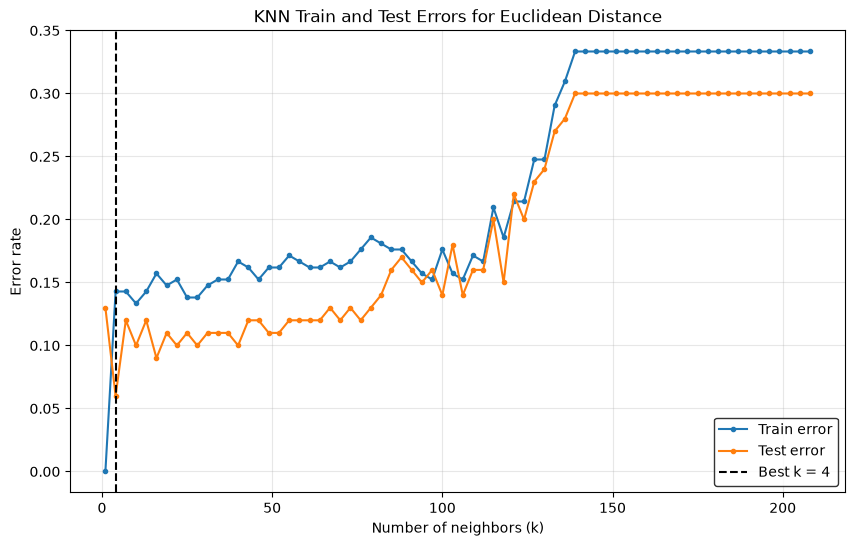

Best k*: 4
Best test error: 0.060

Confusion matrix [ [TN, FP], [FN, TP] ]:
[[25  5]
 [ 1 69]]
True positive rate: 0.986
True negative rate: 0.833
Precision: 0.932
F1-score: 0.958


In [37]:
X_test = test[features]
y_test = test['class']

k_values = list(range(208, 0, -3))
train_errors = []
test_errors = []

for k in k_values:
    knn_model = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
    )
    knn_model.fit(X_train, y_train)
    train_errors.append(1 - knn_model.score(X_train, y_train))
    test_errors.append(1 - knn_model.score(X_test, y_test))

best_index = int(np.argmin(test_errors))
k_star = k_values[best_index]
best_test_error = test_errors[best_index]

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, marker='o', markersize=3, label='Train error')
plt.plot(k_values, test_errors, marker='o', markersize=3, label='Test error')
plt.axvline(k_star, color='black', linestyle='--', label=f'Best k = {k_star}')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Error rate')
plt.title('KNN Train and Test Errors for Euclidean Distance')
plt.legend(frameon=True, edgecolor='black')
plt.grid(alpha=0.3)
plt.show()

best_knn = KNeighborsClassifier(
    n_neighbors=k_star,
    metric='euclidean',
)
best_knn.fit(X_train, y_train)
best_test_predictions = best_knn.predict(X_test)

confusion = confusion_matrix(y_test, best_test_predictions, labels=[0, 1])
tn, fp, fn, tp = confusion.ravel()

true_positive_rate = tp / (tp + fn)
true_negative_rate = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * precision * true_positive_rate / (precision + true_positive_rate)

print(f'Best k*: {k_star}')
print(f'Best test error: {best_test_error:.3f}')
print('\nConfusion matrix [ [TN, FP], [FN, TP] ]:')
print(confusion)
print(f'True positive rate: {true_positive_rate:.3f}')
print(f'True negative rate: {true_negative_rate:.3f}')
print(f'Precision: {precision:.3f}')
print(f'F1-score: {f1_score:.3f}')

(iii) Since the computation time depends on the size of the training set, one may only use a subset of the training set. Plot the *best test error rate*,<sup>3</sup> which is obtained by some value of $k$, against the size of training set, when the size of training set is $N \in \{10, 20, 30, \ldots, 210\}$<sup>4</sup>. Note: for each $N$, select your training set by choosing the first $\lfloor N/3 \rfloor$ rows of Class 0 and the first $N - \lfloor N/3 \rfloor$ rows of Class 1 in the training set you created in 1(b)iii. Also, for each $N$, select the optimal $k$ from a set starting from $k = 1$, increasing by 5. For example, if $N = 200$, the optimal $k$ is selected from $\{1, 6, 11, \ldots, 196\}$. This plot is called a *Learning Curve*.

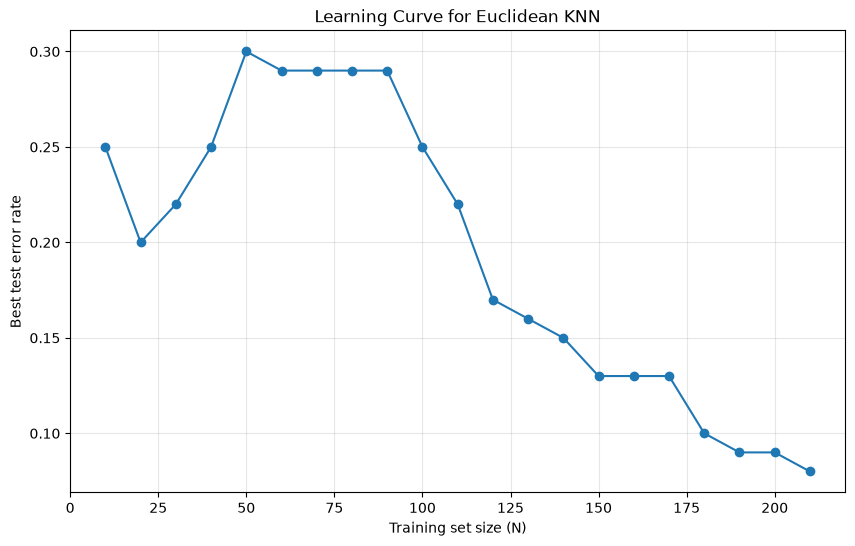

,training_size,best_k,best_test_error
0,10,1,0.25
1,20,6,0.20
2,30,1,0.22
3,40,11,0.25
4,50,26,0.30
5,60,21,0.29
6,70,26,0.29
7,80,31,0.29
8,90,41,0.29
9,100,6,0.25


In [38]:
train_class_0 = train[train['class'] == 0]
train_class_1 = train[train['class'] == 1]

training_sizes = range(10, 211, 10)
best_test_errors = []
best_k_values = []

for training_size in training_sizes:
    class_0_count = training_size // 3
    class_1_count = training_size - class_0_count

    subset_train = pd.concat([
        train_class_0.iloc[:class_0_count],
        train_class_1.iloc[:class_1_count],
    ])

    subset_X_train = subset_train[features]
    subset_y_train = subset_train['class']
    candidate_k_values = range(1, training_size, 5)
    candidate_test_errors = []

    for k in candidate_k_values:
        subset_knn = KNeighborsClassifier(
            n_neighbors=k,
            metric='euclidean',
        )
        subset_knn.fit(subset_X_train, subset_y_train)
        candidate_test_errors.append(1 - subset_knn.score(X_test, y_test))

    best_subset_index = int(np.argmin(candidate_test_errors))
    best_test_errors.append(candidate_test_errors[best_subset_index])
    best_k_values.append(list(candidate_k_values)[best_subset_index])

plt.figure(figsize=(10, 6))
plt.plot(training_sizes, best_test_errors, marker='o')
plt.xlabel('Training set size (N)')
plt.ylabel('Best test error rate')
plt.title('Learning Curve for Euclidean KNN')
plt.grid(alpha=0.3)
plt.show()

learning_curve_results = pd.DataFrame({
    'training_size': list(training_sizes),
    'best_k': best_k_values,
    'best_test_error': best_test_errors,
})
learning_curve_results

## KNN Variations

(i) **Minkowski Distance**

A. Manhattan Distance (p=1)

In [39]:
manhattan_k_values = list(range(1, 197, 5))
manhattan_test_errors = []

for k in manhattan_k_values:
    manhattan_knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='manhattan',
    )
    manhattan_knn.fit(X_train, y_train)
    manhattan_test_errors.append(1 - manhattan_knn.score(X_test, y_test))

best_manhattan_index = int(np.argmin(manhattan_test_errors))
best_manhattan_k = manhattan_k_values[best_manhattan_index]
best_manhattan_test_error = manhattan_test_errors[best_manhattan_index]

manhattan_results = pd.DataFrame({
    'metric': ['Manhattan'],
    'best_k': [best_manhattan_k],
    'test_error': [best_manhattan_test_error],
})

manhattan_results

,metric,best_k,test_error
0,Manhattan,6,0.11


B. Ideal $p$ when $k=k*$

In [40]:
log10_p_values = np.arange(0.1, 1.01, 0.1)
minkowski_p_values = 10 ** log10_p_values
minkowski_test_errors = []

for p in minkowski_p_values:
    minkowski_knn = KNeighborsClassifier(
        n_neighbors=best_manhattan_k,
        metric='minkowski',
        p=p,
    )
    minkowski_knn.fit(X_train, y_train)
    minkowski_test_errors.append(1 - minkowski_knn.score(X_test, y_test))

best_minkowski_index = int(np.argmin(minkowski_test_errors))
best_log10_p = log10_p_values[best_minkowski_index]
best_minkowski_p = minkowski_p_values[best_minkowski_index]
best_minkowski_test_error = minkowski_test_errors[best_minkowski_index]

minkowski_results = pd.DataFrame({
    'log10(p)': log10_p_values,
    'p': minkowski_p_values,
    'test_error': minkowski_test_errors,
})

print(f'Fixed k*: {best_manhattan_k}')
print(f'Best log10(p): {best_log10_p:.1f}')
print(f'Best p: {best_minkowski_p:.3f}')
print(f'Best test error: {best_minkowski_test_error:.3f}')

minkowski_results

Fixed k*: 6
Best log10(p): 0.6
Best p: 3.981
Best test error: 0.060


,log10(p),p,test_error
0,0.1,1.258925,0.09
1,0.2,1.584893,0.09
2,0.3,1.995262,0.08
3,0.4,2.511886,0.08
4,0.5,3.162278,0.08
5,0.6,3.981072,0.06
6,0.7,5.011872,0.07
7,0.8,6.309573,0.08
8,0.9,7.943282,0.09
9,1.0,10.000000,0.09


C. Chebyshev Distance ($p = \infty$)

In [41]:
chebyshev_k_values = list(range(1, 197, 5))
chebyshev_test_errors = []

for k in chebyshev_k_values:
    chebyshev_knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='chebyshev',
    )
    chebyshev_knn.fit(X_train, y_train)
    chebyshev_test_errors.append(1 - chebyshev_knn.score(X_test, y_test))

best_chebyshev_index = int(np.argmin(chebyshev_test_errors))
best_chebyshev_k = chebyshev_k_values[best_chebyshev_index]
best_chebyshev_test_error = chebyshev_test_errors[best_chebyshev_index]

chebyshev_results = pd.DataFrame({
    'metric': ['Chebyshev'],
    'best_k': [best_chebyshev_k],
    'test_error': [best_chebyshev_test_error],
})

chebyshev_results

,metric,best_k,test_error
0,Chebyshev,16,0.08


(ii) **Mahalanobis Distance**

In [42]:
training_covariance = np.cov(X_train, rowvar=False)
inverse_covariance = np.linalg.pinv(training_covariance)

mahalanobis_k_values = list(range(1, 197, 5))
mahalanobis_test_errors = []

for k in mahalanobis_k_values:
    mahalanobis_knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='mahalanobis',
        metric_params={'VI': inverse_covariance},
    )
    mahalanobis_knn.fit(X_train, y_train)
    mahalanobis_test_errors.append(1 - mahalanobis_knn.score(X_test, y_test))

best_mahalanobis_index = int(np.argmin(mahalanobis_test_errors))
best_mahalanobis_k = mahalanobis_k_values[best_mahalanobis_index]
best_mahalanobis_test_error = mahalanobis_test_errors[best_mahalanobis_index]

mahalanobis_results = pd.DataFrame({
    'metric': ['Mahalanobis'],
    'best_k': [best_mahalanobis_k],
    'test_error': [best_mahalanobis_test_error],
})

mahalanobis_results

,metric,best_k,test_error
0,Mahalanobis,1,0.17


(e) The majority polling decision can be replaced by weighted decision, in which the weight of each point in voting is inversely proportional to its distance from the query/test data point. In this case, closer neighbors of a query point will have a greater influence than neighbors which are further away. Use weighted voting with Euclidean, Manhattan, and Chebyshev distances and report the best test errors when $k \in \{1, 6, 11, 16, \ldots, 196\}$.

In [43]:
weighted_k_values = list(range(1, 197, 5))
weighted_metrics = ['euclidean', 'manhattan', 'chebyshev']
weighted_results = []

for metric in weighted_metrics:
    weighted_test_errors = []

    for k in weighted_k_values:
        weighted_knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            weights='distance',
        )
        weighted_knn.fit(X_train, y_train)
        weighted_test_errors.append(1 - weighted_knn.score(X_test, y_test))

    best_weighted_index = int(np.argmin(weighted_test_errors))
    weighted_results.append({
        'metric': metric.title(),
        'best_k': weighted_k_values[best_weighted_index],
        'test_error': weighted_test_errors[best_weighted_index],
    })

weighted_results = pd.DataFrame(weighted_results)
weighted_results

,metric,best_k,test_error
0,Euclidean,6,0.10
1,Manhattan,26,0.10
2,Chebyshev,16,0.11


(f) What is the lowest training error rate you achieved in this homework?

In [44]:
selected_training_errors = []

selected_models = [
    ('Euclidean', 'euclidean', k_star, None, 'uniform'),
    ('Manhattan', 'manhattan', best_manhattan_k, None, 'uniform'),
    ('Minkowski', 'minkowski', best_manhattan_k, None, 'uniform'),
    ('Chebyshev', 'chebyshev', best_chebyshev_k, None, 'uniform'),
    ('Mahalanobis', 'mahalanobis', best_mahalanobis_k, {'VI': inverse_covariance}, 'uniform'),
    ('Weighted Euclidean', 'euclidean', weighted_results.loc[0, 'best_k'], None, 'distance'),
    ('Weighted Manhattan', 'manhattan', weighted_results.loc[1, 'best_k'], None, 'distance'),
    ('Weighted Chebyshev', 'chebyshev', weighted_results.loc[2, 'best_k'], None, 'distance'),
]

for model_name, metric_name, selected_k, metric_params, weights in selected_models:
    selected_model = KNeighborsClassifier(
        n_neighbors=int(selected_k),
        metric=metric_name,
        p=best_minkowski_p if metric_name == 'minkowski' else 2,
        metric_params=metric_params,
        weights=weights,
    )
    selected_model.fit(X_train, y_train)
    selected_training_errors.append({
        'process': model_name,
        'selected_k': int(selected_k),
        'training_error': 1 - selected_model.score(X_train, y_train),
    })

for training_size, selected_k in zip(training_sizes, best_k_values):
    class_0_count = training_size // 3
    class_1_count = training_size - class_0_count
    subset_train = pd.concat([
        train_class_0.iloc[:class_0_count],
        train_class_1.iloc[:class_1_count],
    ])
    subset_model = KNeighborsClassifier(
        n_neighbors=selected_k,
        metric='euclidean',
    )
    subset_model.fit(subset_train[features], subset_train['class'])
    selected_training_errors.append({
        'process': f'Learning curve (N={training_size})',
        'selected_k': selected_k,
        'training_error': 1 - subset_model.score(
            subset_train[features],
            subset_train['class'],
        ),
    })

selected_training_errors = pd.DataFrame(selected_training_errors)
lowest_training_error = selected_training_errors['training_error'].min()

print(
    'Lowest training error rate at the selected test-optimal k values: '
    f'{lowest_training_error:.3f}'
)
selected_training_errors

Lowest training error rate at the selected test-optimal k values: 0.000


,process,selected_k,training_error
0,Euclidean,4,0.142857
1,Manhattan,6,0.138095
2,Minkowski,6,0.152381
3,Chebyshev,16,0.152381
4,Mahalanobis,1,0.000000
5,Weighted Euclidean,6,0.000000
6,Weighted Manhattan,26,0.000000
7,Weighted Chebyshev,16,0.000000
8,Learning curve (N=10),1,0.000000
9,Learning curve (N=20),6,0.150000


The lowest training error rate was obtained by Mahalanobis and the weighted KNN models at their $k*$ values. This makes sense because each training observation inlcuded itself among its own neighbours, so the zero distance gave it the highest possible weight. A 0 zero training error didn't mean it was the best hypothesis (I've added a table for this because I was curious).

In [45]:
test_error_table = pd.DataFrame({
    'metric': [
        'Euclidean',
        'Manhattan',
        'Minkowski (best p)',
        'Chebyshev',
        'Mahalanobis',
        'Weighted Euclidean',
        'Weighted Manhattan',
        'Weighted Chebyshev',
    ],
    'best_k': [
        k_star,
        best_manhattan_k,
        best_manhattan_k,
        best_chebyshev_k,
        best_mahalanobis_k,
        weighted_results.loc[0, 'best_k'],
        weighted_results.loc[1, 'best_k'],
        weighted_results.loc[2, 'best_k'],
    ],
    'test_error': [
        best_test_error,
        best_manhattan_test_error,
        best_minkowski_test_error,
        best_chebyshev_test_error,
        best_mahalanobis_test_error,
        weighted_results.loc[0, 'test_error'],
        weighted_results.loc[1, 'test_error'],
        weighted_results.loc[2, 'test_error'],
    ],
})

test_error_table

,metric,best_k,test_error
0,Euclidean,4,0.06
1,Manhattan,6,0.11
2,Minkowski (best p),6,0.06
3,Chebyshev,16,0.08
4,Mahalanobis,1,0.17
5,Weighted Euclidean,6,0.10
6,Weighted Manhattan,26,0.10
7,Weighted Chebyshev,16,0.11
